### Imports

In [1]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Folder tree

In [2]:
dataset = Path("../data/raw/UBFC_Phys/s46")

for f in sorted(dataset.iterdir()):
    print(f.name)

bvp_s46_T1.csv
bvp_s46_T2.csv
bvp_s46_T3.csv
eda_s46_T1.csv
eda_s46_T2.csv
eda_s46_T3.csv
info_s46.txt
selfReportedAnx_s46.csv
vid_s46_T1.avi
vid_s46_T2.avi
vid_s46_T3.avi


---
### Video Analysis

(1024, 1024, 3)


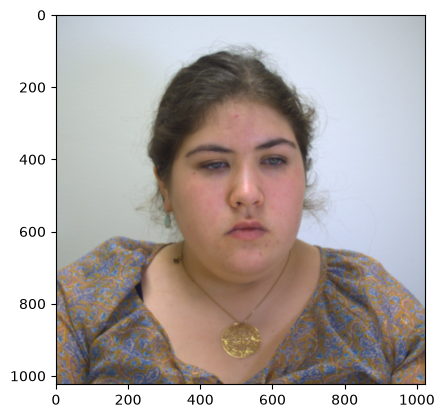

In [3]:
cap = cv2.VideoCapture(str(dataset / "vid_s46_T1.avi"))

ret, frame = cap.read()

print(frame.shape)

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [4]:
# Get frames per second (FPS)
fps = cap.get(cv2.CAP_PROP_FPS)

# Get total frame count
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Calculate duration in seconds
duration = frame_count / fps

print(f"FPS: {fps}")
print(f"Total frames: {frame_count}")
print(f"Duration (seconds): {duration}")

FPS: 35.138
Total frames: 6325
Duration (seconds): 180.00455347487053


**Info:**

Resolution : 1024 x 1024 

AVI video file

FPS : 35

Duration : 180.00 seconds

---

### Read BVP

In [5]:
bvp_t1 = pd.read_csv(dataset / "bvp_s46_T1.csv", header=None)[0]
bvp_t2 = pd.read_csv(dataset / "bvp_s46_T2.csv", header=None)[0]
bvp_t3 = pd.read_csv(dataset / "bvp_s46_T3.csv", header=None)[0]

In [6]:
bvp_t1.info()
bvp_t1.head()

<class 'pandas.Series'>
RangeIndex: 11520 entries, 0 to 11519
Series name: 0
Non-Null Count  Dtype  
--------------  -----  
11520 non-null  float64
dtypes: float64(1)
memory usage: 90.1 KB


0    -2.01
1    -4.54
2    -6.85
3    -8.90
4   -10.76
Name: 0, dtype: float64

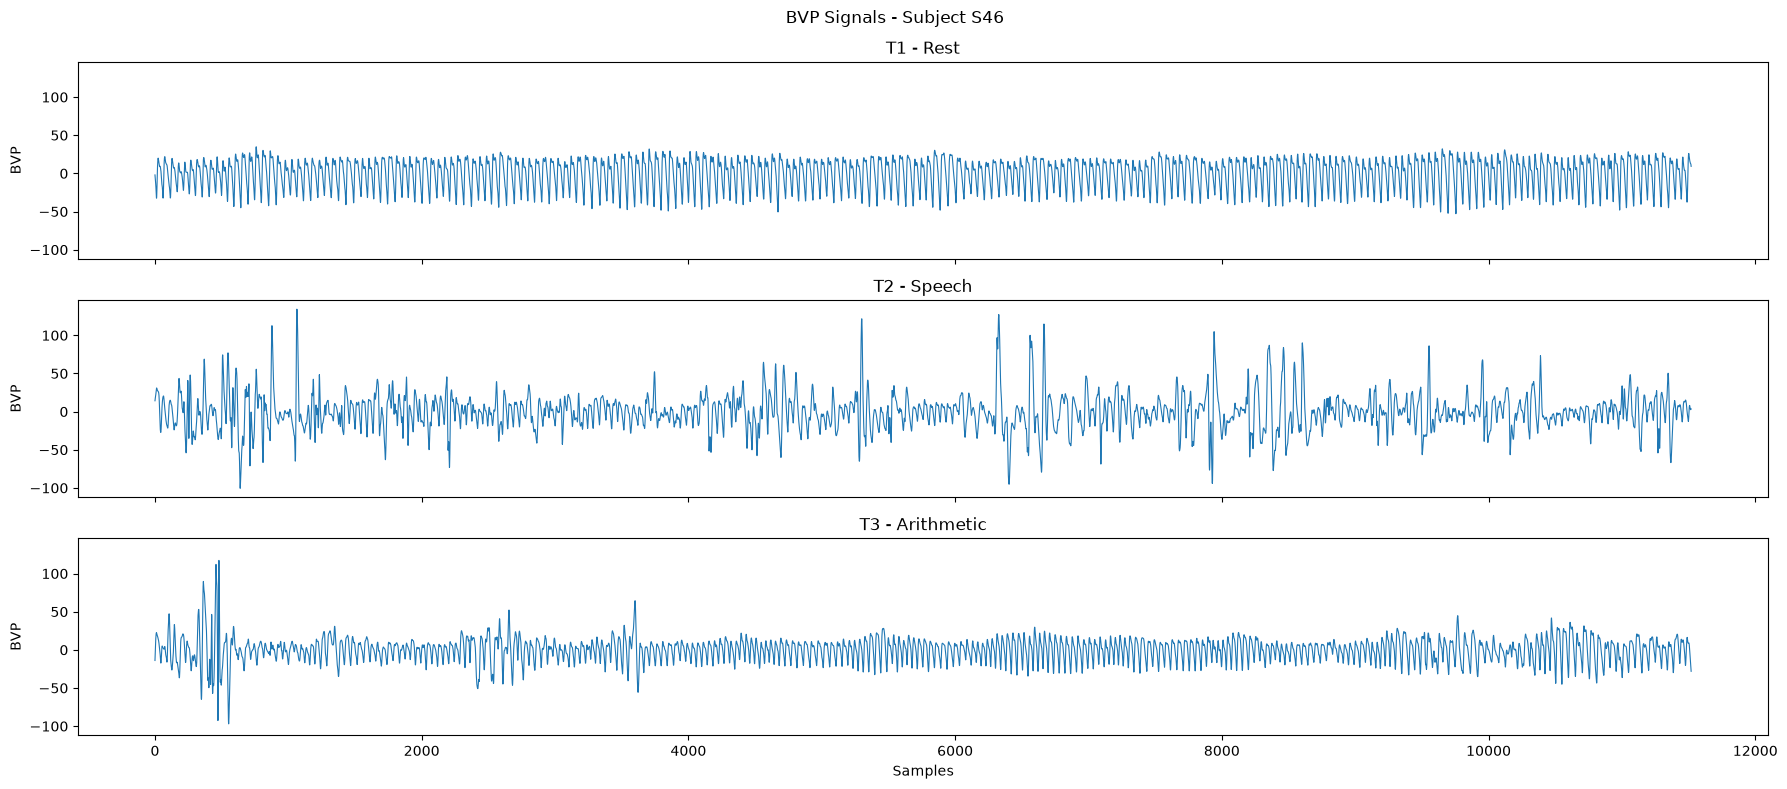

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(18, 8), sharex=True, sharey=True)

signals = [bvp_t1, bvp_t2, bvp_t3]
titles = ["T1 - Rest", "T2 - Speech", "T3 - Arithmetic"]

for i in range(3):
    ax[i].plot(signals[i], lw=0.8)
    ax[i].set_title(titles[i])
    ax[i].set_ylabel("BVP")

ax[-1].set_xlabel("Samples")

plt.suptitle("BVP Signals - Subject S46")
plt.tight_layout()
plt.show()

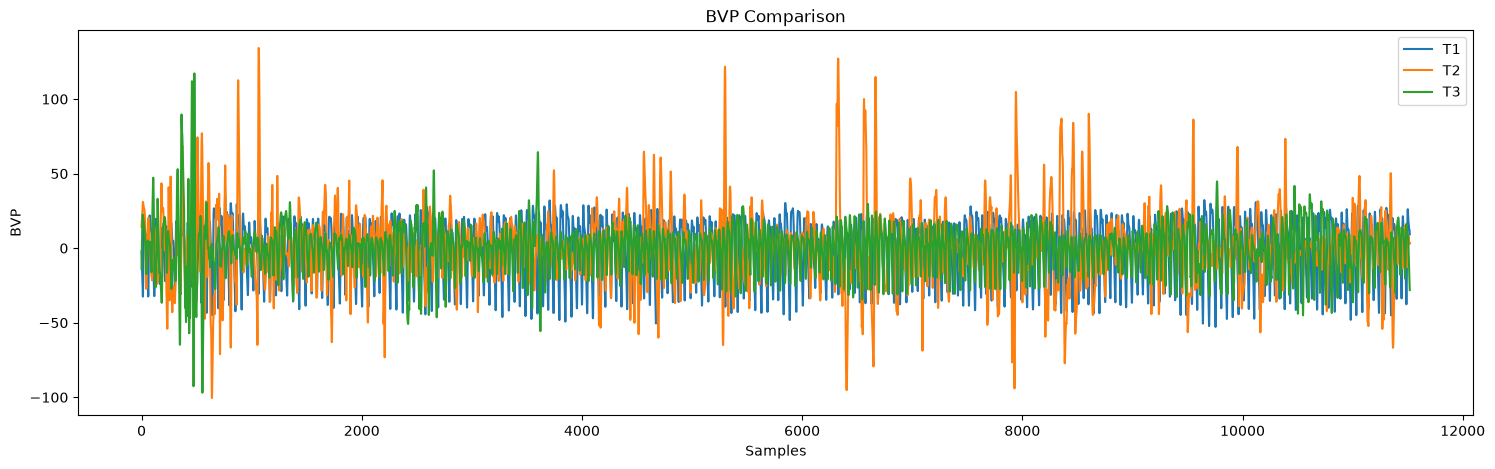

In [8]:
plt.figure(figsize=(18,5))

plt.plot(bvp_t1, label="T1")
plt.plot(bvp_t2, label="T2")
plt.plot(bvp_t3, label="T3")

plt.title("BVP Comparison")
plt.xlabel("Samples")
plt.ylabel("BVP")
plt.legend()

plt.show()

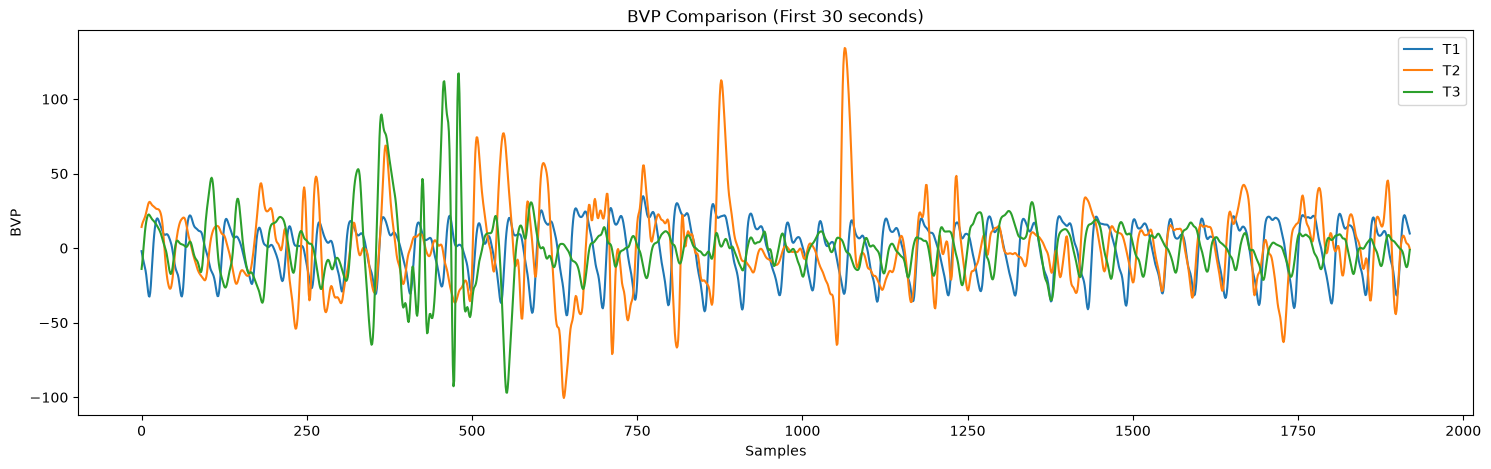

In [9]:
N = 64 * 30      # first 30 seconds

plt.figure(figsize=(18,5))

plt.plot(bvp_t1[:N], label="T1")
plt.plot(bvp_t2[:N], label="T2")
plt.plot(bvp_t3[:N], label="T3")

plt.title("BVP Comparison (First 30 seconds)")
plt.xlabel("Samples")
plt.ylabel("BVP")
plt.legend()

plt.show()

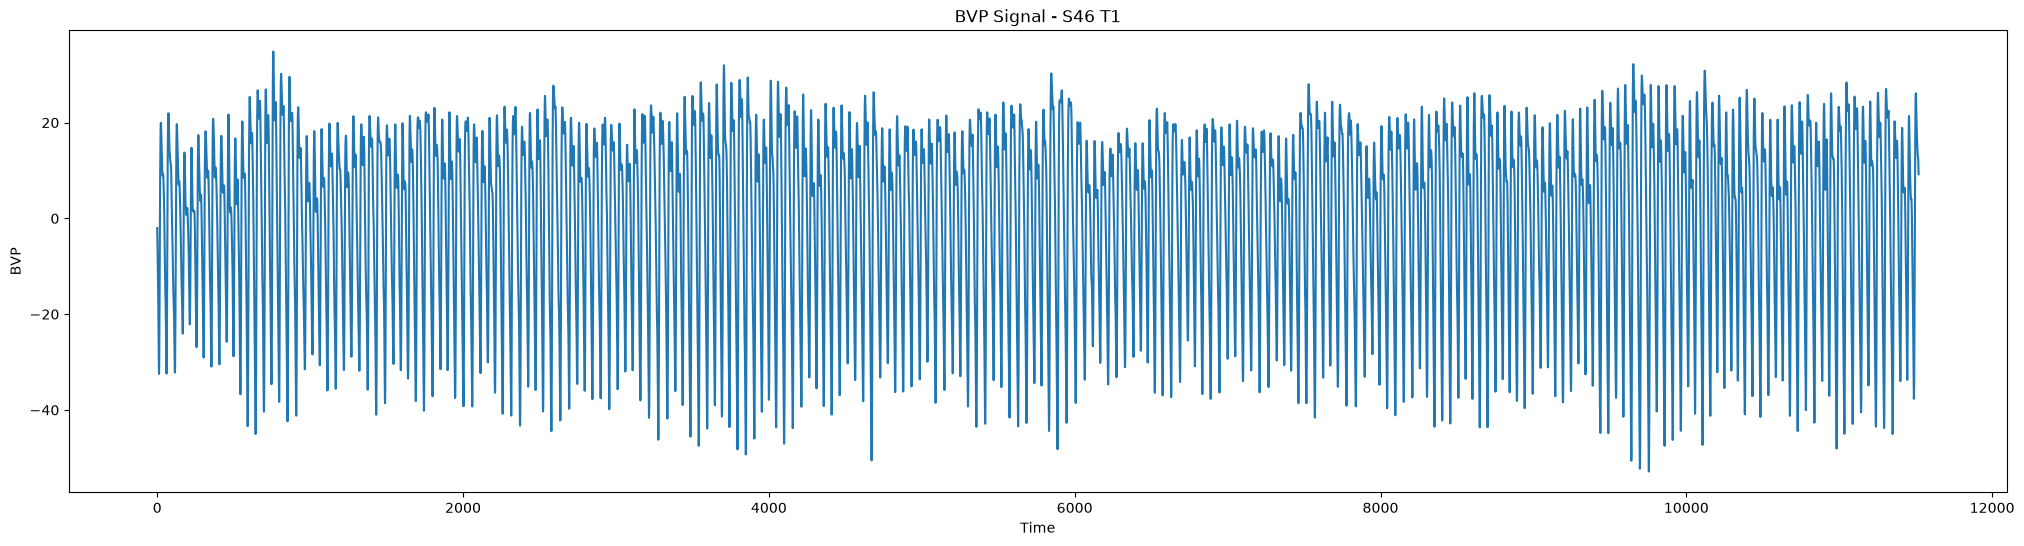

In [10]:
plt.figure(figsize=(25, 6))
plt.plot(bvp_t1)
plt.xlabel('Time')
plt.ylabel('BVP')
plt.title('BVP Signal - S46 T1')

plt.show()

In [11]:
print(round(bvp_t1.shape[0]/duration) , "Hz")
bvp_t1.describe()

64 Hz


count    11520.000000
mean        -0.011577
std         18.955745
min        -52.850000
25%        -15.040000
50%          6.200000
75%         15.470000
max         34.850000
Name: 0, dtype: float64

---

### Read EDA

In [12]:
eda_t1 = pd.read_csv(dataset / "eda_s46_T1.csv", header=None)[0]
eda_t2 = pd.read_csv(dataset / "eda_s46_T2.csv", header=None)[0]
eda_t3 = pd.read_csv(dataset / "eda_s46_T3.csv", header=None)[0]

In [13]:
eda_t1.info()
eda_t1.head()

<class 'pandas.Series'>
RangeIndex: 720 entries, 0 to 719
Series name: 0
Non-Null Count  Dtype  
--------------  -----  
720 non-null    float64
dtypes: float64(1)
memory usage: 5.8 KB


0    0.039702
1    0.039702
2    0.038421
3    0.039702
4    0.038421
Name: 0, dtype: float64

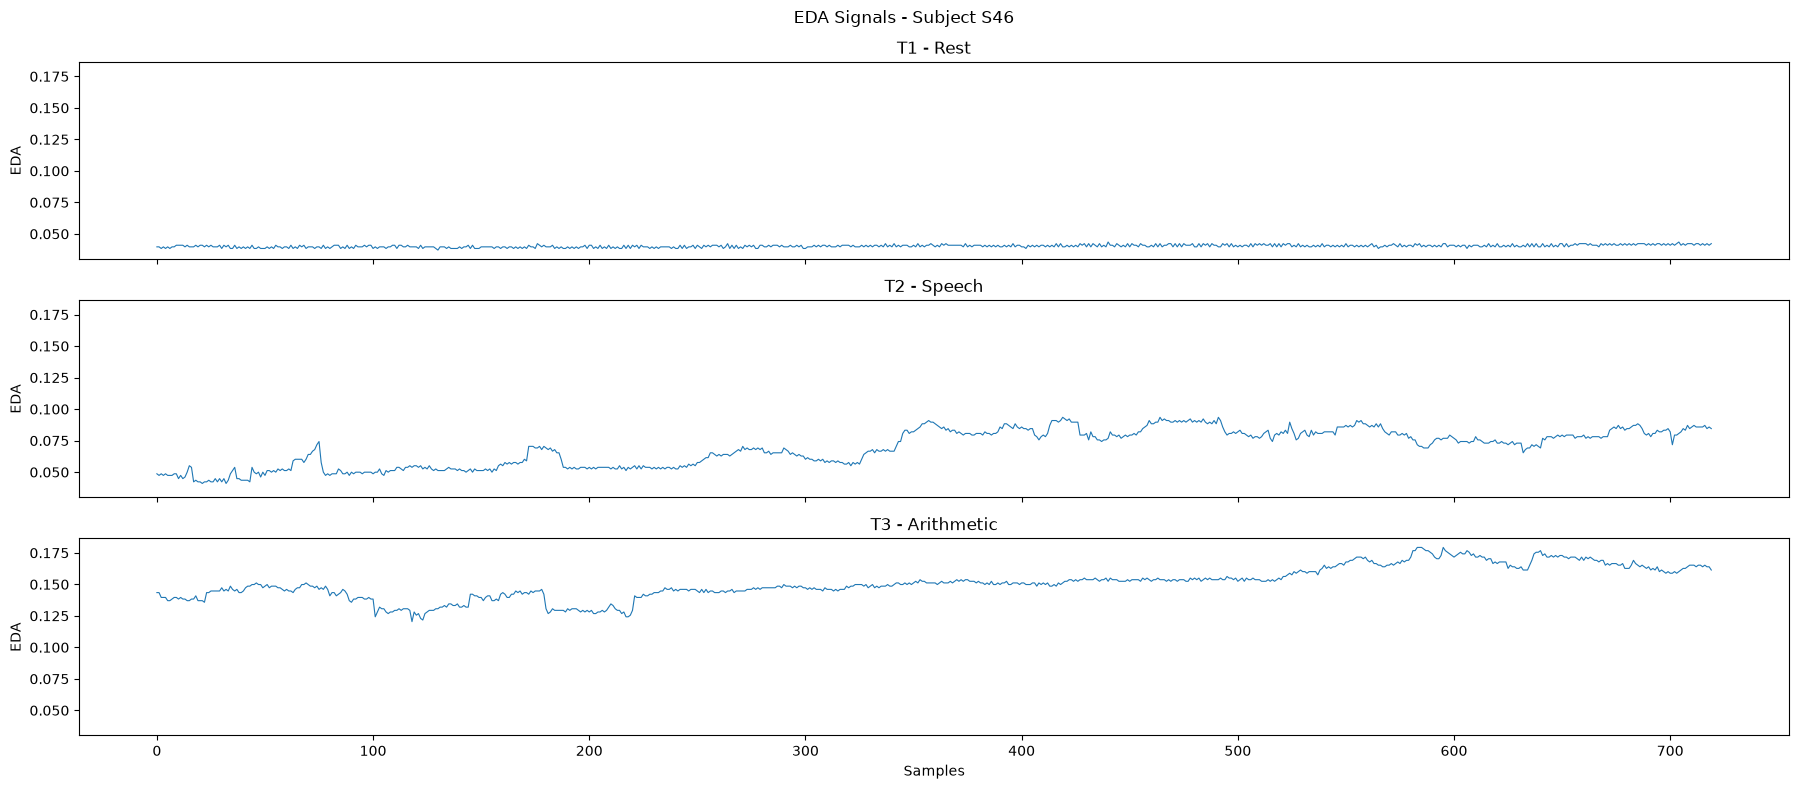

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(18, 8), sharex=True, sharey=True)

signals = [eda_t1, eda_t2, eda_t3]
titles = ["T1 - Rest", "T2 - Speech", "T3 - Arithmetic"]

for i in range(3):
    ax[i].plot(signals[i], lw=0.8)
    ax[i].set_title(titles[i])
    ax[i].set_ylabel("EDA")

ax[-1].set_xlabel("Samples")

plt.suptitle("EDA Signals - Subject S46")
plt.tight_layout()
plt.show()

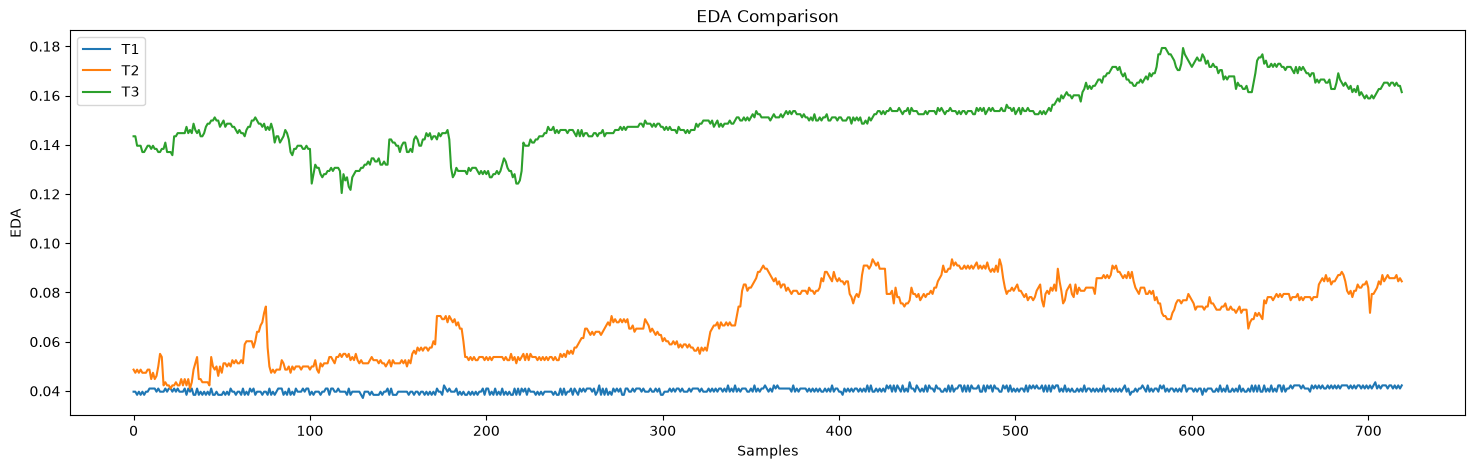

In [15]:
plt.figure(figsize=(18,5))

plt.plot(eda_t1, label="T1")
plt.plot(eda_t2, label="T2")
plt.plot(eda_t3, label="T3")

plt.title("EDA Comparison")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.legend()

plt.show()

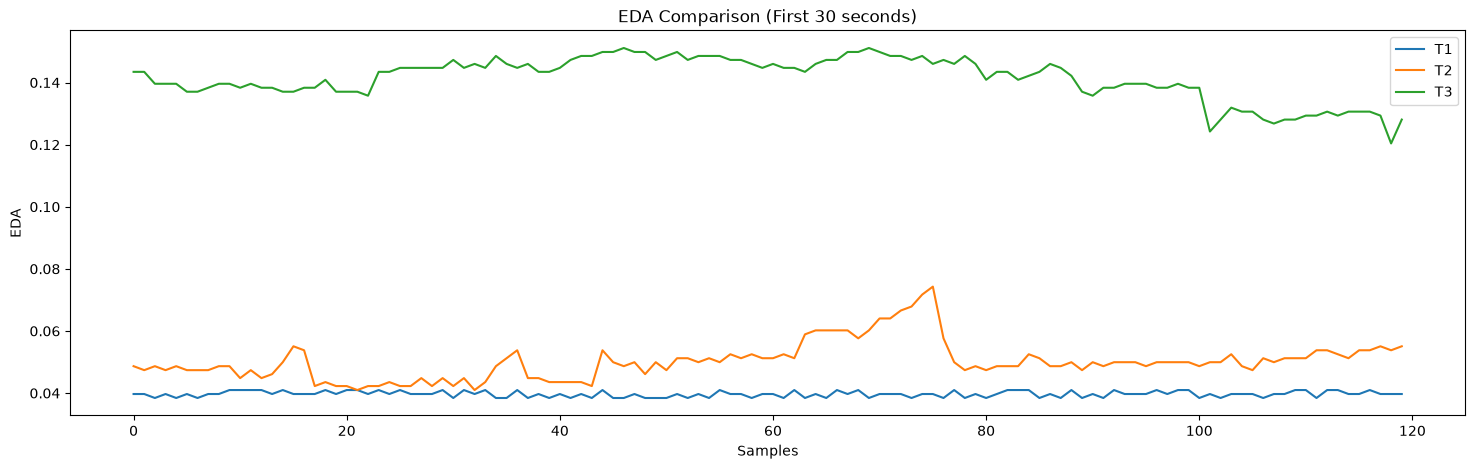

In [16]:
N = 4 * 30      # first 30 seconds

plt.figure(figsize=(18,5))

plt.plot(eda_t1[:N], label="T1")
plt.plot(eda_t2[:N], label="T2")
plt.plot(eda_t3[:N], label="T3")

plt.title("EDA Comparison (First 30 seconds)")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.legend()

plt.show()

In [17]:
print(round(eda_t1.shape[0]/duration) , "Hz")

eda_t1.describe()

4 Hz


count    720.000000
mean       0.040330
std        0.001164
min        0.037141
25%        0.039702
50%        0.039702
75%        0.040983
max        0.043544
Name: 0, dtype: float64

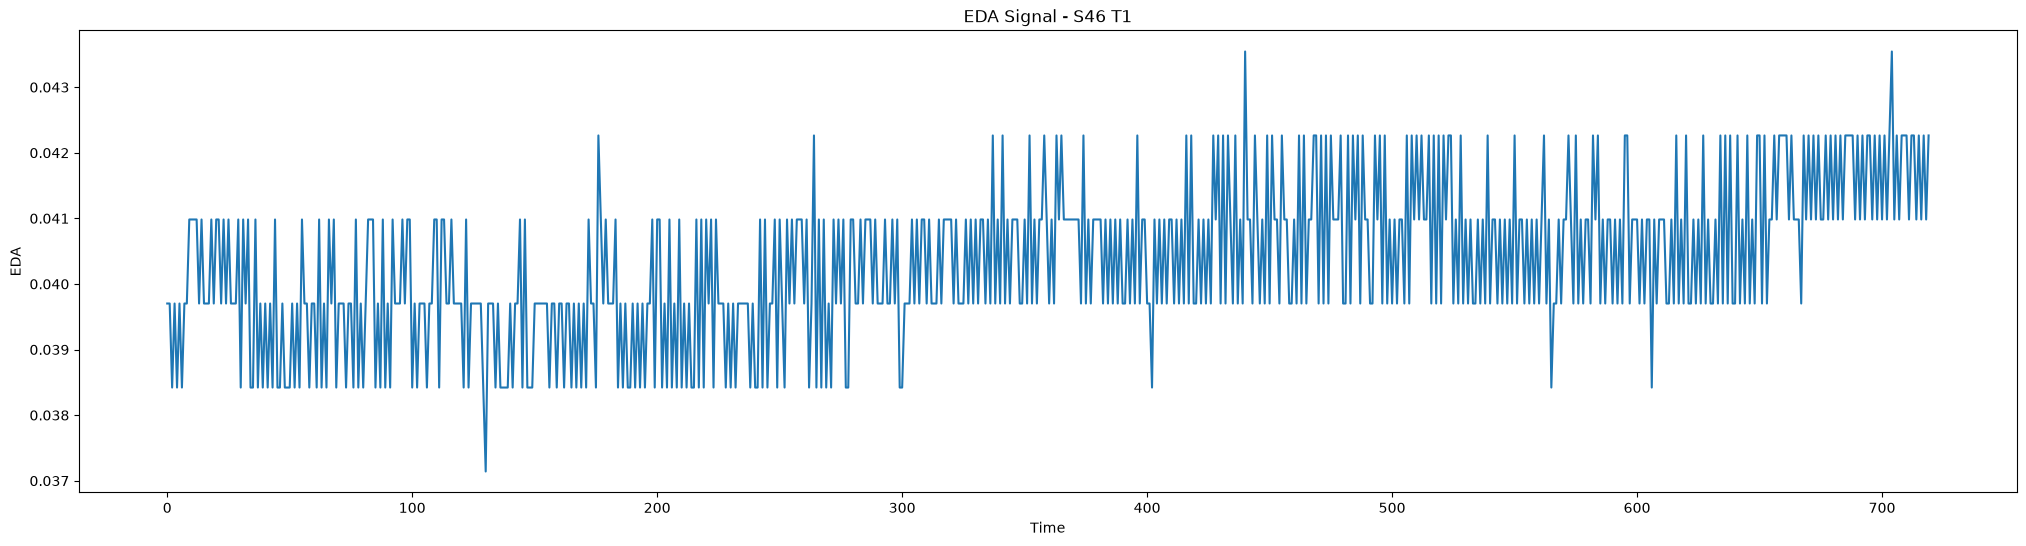

In [18]:
plt.figure(figsize=(25, 6))
plt.plot(eda_t1)
plt.xlabel('Time')
plt.ylabel('EDA')
plt.title('EDA Signal - S46 T1')

plt.show()

---

### Read `info_s46.txt`


In [19]:
info_file = dataset / "info_s46.txt"

with open(info_file, "r") as f:
    info = f.read()

print(info)

s46
f
ctrl
2019_03_05
14_17_14


#### Observation

- Subject ID: s46
- Gender: F
- Type: Control
- Other metadata: 5 March 2019, 14:17:14

### Read Self Reported

In [20]:
questionnaire = pd.read_csv(dataset / "selfReportedAnx_s46.csv", header=None)

questionnaire.columns = ["Pre-session", "Post-session"]
questionnaire.index = ["Cognitive Anxiety", "Somatic Anxiety", "Self-Confidence"]

print("Average scores: ")
questionnaire

Average scores: 


,Pre-session,Post-session
Cognitive Anxiety,2.000,1.571
Somatic Anxiety,2.000,1.714
Self-Confidence,2.667,2.667


- Cognitive anxiety decreased slightly.
- Somatic anxiety also decreased slightly.
- Self-Confidence : No change.

The paper reports that participants in the **control scenario** generally showed little or no increase in anxiety scores compared with the test scenario, especially for somatic anxiety.

---

In [22]:
video_duration = frame_count / fps
bvp_duration = len(bvp_t1) / 64
eda_duration = len(eda_t1) / 4

print(f"Video Duration : {video_duration:.2f} s")
print(f"BVP Duration   : {bvp_duration:.2f} s")
print(f"EDA Duration   : {eda_duration:.2f} s")

Video Duration : 180.00 s
BVP Duration   : 180.00 s
EDA Duration   : 180.00 s


In [23]:
import numpy as np

t_video = np.arange(frame_count) / fps
t_bvp = np.arange(len(bvp_t1)) / 64
t_eda = np.arange(len(eda_t1)) / 4

print(t_video[0], t_video[-1])
print(t_bvp[0], t_bvp[-1])
print(t_eda[0], t_eda[-1])

0.0 179.97609425692983
0.0 179.984375
0.0 179.75


---

In [30]:
print("="*50)
print("UBFC-Phys Dataset Summary")
print("="*50)

print(f"Video Resolution : {frame.shape[1]} x {frame.shape[0]}")
print(f"FPS              : {fps:.2f}")
print(f"Frames           : {frame_count}")
print(f"Duration         : {video_duration:.2f} s")

print()

print(f"BVP Samples      : {len(bvp_t1)}")
print(f"BVP Fs           : {len(bvp_t1)/video_duration:.2f} Hz")

print()

print(f"EDA Samples      : {len(eda_t1)}")
print(f"EDA Fs           : {len(eda_t1)/video_duration:.2f} Hz")

print("\n\nAverage Scores:\n", questionnaire)

UBFC-Phys Dataset Summary
Video Resolution : 1024 x 1024
FPS              : 35.14
Frames           : 6325
Duration         : 180.00 s

BVP Samples      : 11520
BVP Fs           : 64.00 Hz

EDA Samples      : 720
EDA Fs           : 4.00 Hz


Average Scores:
                    Pre-session  Post-session
Cognitive Anxiety        2.000         1.571
Somatic Anxiety          2.000         1.714
Self-Confidence          2.667         2.667
